In [26]:
import os
import random
import numpy as np
import json

import PIL 
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torchvision import transforms

os.chdir('/engram/nklab/pf2477/brain_decoding/')
from whole_brain_encoder.utils.args import get_default_args
from brain_adapter.dataset import nsd_dataset_avg

In [27]:
subj = 1
nsd_corr_path = f'brain_adapter/brain_encoder_corr/{subj}_nsd_test_labeled_rois.json'
imagenet_corr_path = f'brain_adapter/brain_encoder_corr/{subj}_imagenet_labeled_rois.json'
image_path_file = f'brain_adapter/brain_encoder_corr/{subj}_imagenet_paths.txt'

transforms_compose = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224)
])

nsd_stats = {}
with open(nsd_corr_path, "r") as f:
    data = json.load(f)
    nsd_stats[subj] = data["summary_statistics"]
    nsd_stats[subj]['individual_scores'] = data['individual_scores']

imagenet_stats = {}
with open(imagenet_corr_path, "r") as f:
    data = json.load(f)
    imagenet_stats[subj] = data["summary_statistics"]
    imagenet_stats[subj]['individual_scores'] = data['individual_scores']

with open(image_path_file, "r") as f:
    imagenet_image_paths = f.read().splitlines()

args = get_default_args()
args.subj = subj
args.data_dir = "/engram/nklab/datasets/natural_scene_dataset/model_training_datasets/neural_data"
args.imgs_dir = "/engram/nklab/datasets/natural_scene_dataset/nsddata_stimuli/stimuli/nsd"
args.parcel_dir = "/engram/nklab/algonauts/ethan/whole_brain_encoder/parcels/schaefer"
args.hemi = None
test_dataset = nsd_dataset_avg(args, transform=None, split="test")


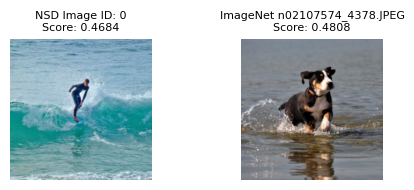

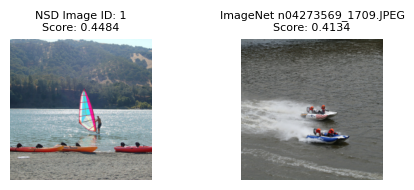

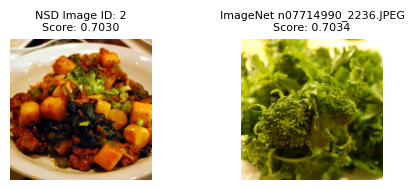

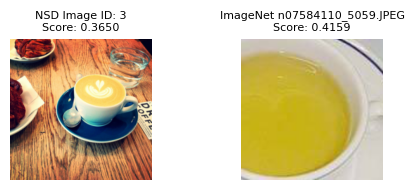

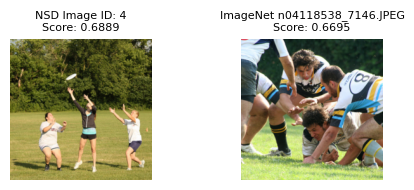

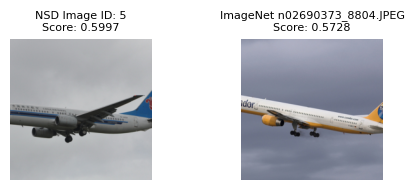

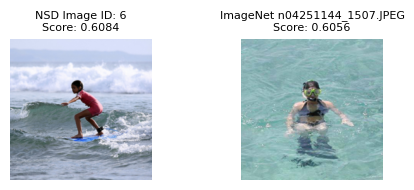

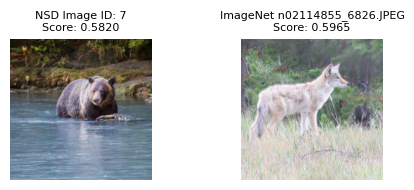

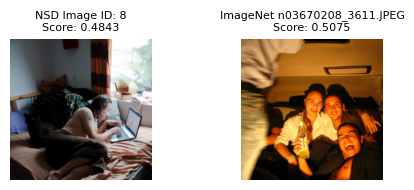

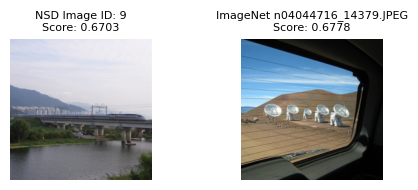

In [32]:


num_images = 10
# indices = [random.randint(0, len(test_dataset) - 1) for _ in range(num_images)]
indices = list(range(10))
for i in indices:
    img, _ = test_dataset[i]

    # print(img.shape, img.dtype, type(img))
    # print(imagenet_image_paths[i])
    # print("NSD scores: ", nsd_stats[subj]['individual_scores'][i])
    # print("ImageNet scores: ", imagenet_stats[subj]['individual_scores'][i])

    imagenet_img = PIL.Image.open(imagenet_image_paths[i]).convert('RGB')
    imagenet_img = transforms_compose(imagenet_img)
    nsd_img = transforms_compose(transforms.ToPILImage()(img))

    fig, axes = plt.subplots(1, 2, figsize=(5, 2))
    
    
    axes[0].imshow(nsd_img)
    axes[0].set_title(
        f"NSD Image ID: {i}\nScore: {nsd_stats[subj]['individual_scores'][i]:.4f}",
        fontsize=8)
    axes[0].axis('off')
    
    axes[1].imshow(imagenet_img)
    axes[1].set_title(f"ImageNet {imagenet_image_paths[i].split('/')[-1]}\nScore: {imagenet_stats[subj]['individual_scores'][i]:.4f}",
                      fontsize=8)
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

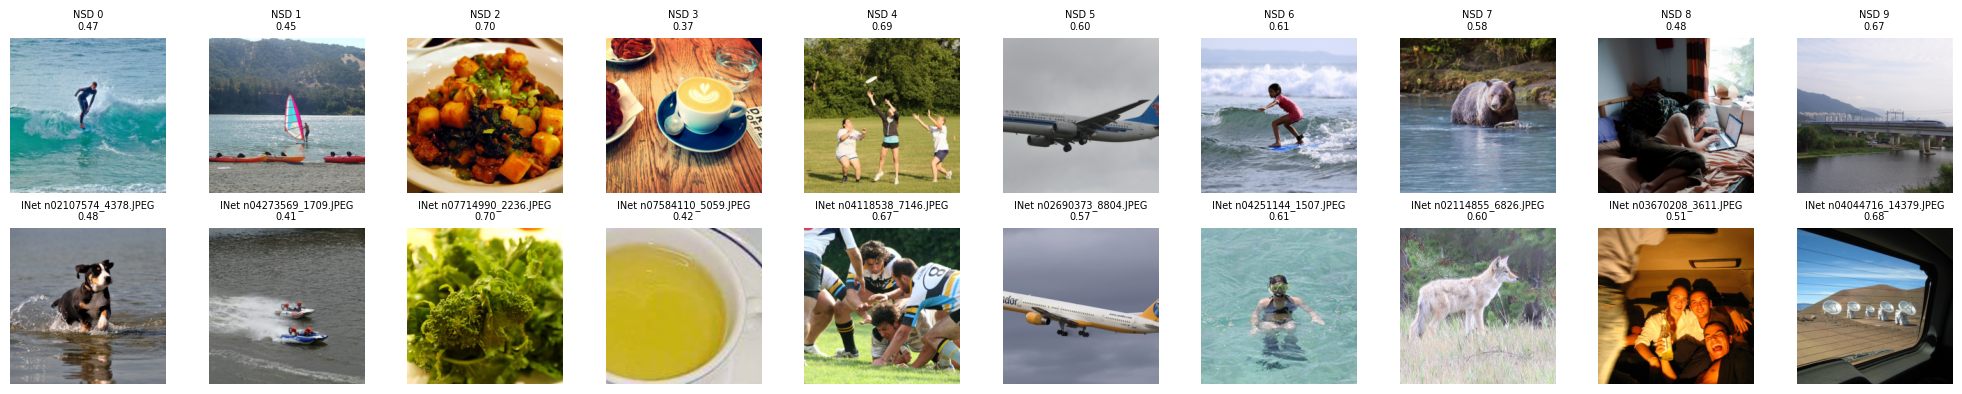

In [34]:
import matplotlib.pyplot as plt
import PIL
import random

num_images = 10
indices = list(range(num_images))  # or use random indices

fig, axes = plt.subplots(2, num_images, figsize=(num_images * 2, 4))

for col, i in enumerate(indices):
    img, _ = test_dataset[i]

    # Load images
    imagenet_img = PIL.Image.open(imagenet_image_paths[i]).convert('RGB')
    imagenet_img = transforms_compose(imagenet_img)
    nsd_img = transforms_compose(transforms.ToPILImage()(img))

    # Top row: NSD
    axes[0, col].imshow(nsd_img)
    axes[0, col].set_title(f"NSD {i}\n{nsd_stats[subj]['individual_scores'][i]:.2f}", fontsize=7)
    axes[0, col].axis('off')

    # Bottom row: ImageNet
    axes[1, col].imshow(imagenet_img)
    axes[1, col].set_title(f"INet {imagenet_image_paths[i].split('/')[-1]}\n{imagenet_stats[subj]['individual_scores'][i]:.2f}", fontsize=7)
    axes[1, col].axis('off')

plt.tight_layout()
plt.show()
